In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from waymo_agent import *

In [3]:
from waymo_agent.osmnx.inspect import *
from waymo_agent.osmnx.osmnx_constants import *
from waymo_agent.osmnx.sparsify import *
from waymo_agent.osmnx.utils import _max_speed_int

In [4]:
G_raw = ox.graph_from_place(
    "Manhattan, New York, USA",
    network_type="drive",
    simplify=True,
)


print(f"Nodes: {G_raw.number_of_nodes()}")
print(f"Edges: {G_raw.number_of_edges()}")

Nodes: 4619
Edges: 9901


## Basic Save / Load

In [5]:
MAP_DIR

PosixPath('/Users/Akseldkw/coding/Columbia/RL-Project/maps')

In [6]:
ox.save_graphml(G_raw, filepath=MAP_DIR / MANHATTAN_RAW_GRAPH)

In [7]:
G_out = ox.load_graphml(filepath=MAP_DIR / MANHATTAN_RAW_GRAPH)

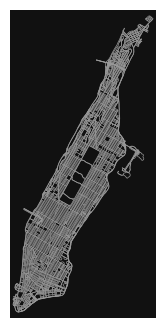

In [8]:
fig, ax = ox.plot_graph(G_out, node_size=0, edge_linewidth=0.5, figsize=(4, 4))

## Preprocess Graph

In [9]:
G = preprocess_graph(G_raw)

In [10]:
# inspect_graph(G)

In [11]:
# plot_maxspeed(G)

In [12]:
ox.save_graphml(G, filepath=MAP_DIR / MANHATTAN_PROCESSED_GRAPH)

## Sparsify Graph

In [13]:
G = sparsify_graph(G)

Removing 4727 non-major edges...
Graph after edge removal: G_sparsified.number_of_nodes()=3517, G_sparsified.number_of_edges()=5173
Cleaning all edge attributes before simplification...
Cleaning all edge attributes before simplification...
Removing 110 isolated or pass-through nodes...
Cleaning all edge attributes before simplification...
Final simplified graph: G_ret.number_of_nodes()=772, G_ret.number_of_edges()=1609


In [14]:
sparse_graph_name = MANHATTAN_SPARSE_GRAPH.format(G.number_of_nodes())
sparse_graph_name

'manhattan-sparse-772-nodes.graphml'

In [15]:
ox.save_graphml(G, filepath=MAP_DIR / sparse_graph_name)

#### Load Sparse Graph

In [16]:
G = ox.load_graphml(filepath=MAP_DIR / sparse_graph_name)

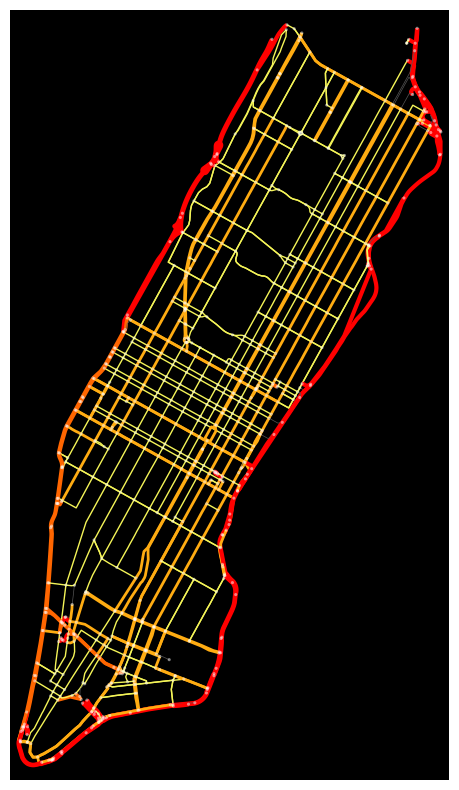

In [17]:
edge_colors, edge_widths = OSMNXConstants.get_edge_colors(G)
fig, ax = ox.plot_graph(
    G,
    edge_color=edge_colors,
    edge_linewidth=edge_widths,
    **OX_PLOT_DEFAULTS,
)